<p align="center"> <img src="Data_Visualization.png" width="1000"/> </p>

##### The exploratory data analysis (EDA) phase focuses on understanding data patterns, trends, and relationships through statistical summaries and visualizations. Key analyses include sales and return trends over time, customer behavior, product performance, and key KPIs such as revenue and return rate. This phase helps uncover insights, identify anomalies, and support data-driven decision-making.

<h2 style="color:white; background-color:#2E86C1; padding:10px; border-radius:5px;"> 📊 Exploratory Data Analysis </h2>

1) Basic Dataset Overview
2) Data Validation
3) Split Data
4) Feature Engineering
5) Analyze Monthly Sales
6) Analyze Return Trend Analysis
7) Analyze Return Rate in(%)
8) Visualize Total Orders
9) Visualize Total Customers
10) Visualize Average Order Value
11) Analyze Top Selling Products
12) Analyze Product Return Trend
13) Analyze Monthly Revenue Trend
14) Analyze Sales vs Returns comparision
15) Analyze Most Returned Products
16) Analyze Return Rate Per Product
17) Analyze Customers Analysis
18) Analyze Country Analysis
19) Visualize Distribution Analysis
20) Visualize Price Distribution
21) Analyze Unit Price vs Quantity

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> Import Various Modules</h2> 

In [67]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> Load Clean Dataset</h2>

In [68]:
df = pd.read_csv("clean_retail_online_sales.csv")

print(df.shape)
df.head()

(460897, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 1) Basic Dataset Overview </h2>

In [69]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460897 entries, 0 to 460896
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    460897 non-null  int64  
 1   StockCode    460897 non-null  object 
 2   Description  460897 non-null  object 
 3   Quantity     460897 non-null  int64  
 4   InvoiceDate  460897 non-null  object 
 5   UnitPrice    460897 non-null  float64
 6   CustomerID   460897 non-null  int64  
 7   Country      460897 non-null  object 
 8   Revenue      460897 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 31.6+ MB


,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue
count,460897.000000,460897.000000,460897.000000,460897.000000,460897.000000
mean,560097.826358,5.999757,2.593063,15310.038820,11.701845
std,13417.598138,9.567215,1.931163,1477.431242,13.174033
min,536365.000000,-990.000000,0.000000,12347.000000,-0.000000
25%,548017.000000,1.000000,1.250000,14415.000000,3.300000
50%,560824.000000,3.000000,2.080000,15287.000000,8.200000
75%,571940.000000,10.000000,3.750000,16295.000000,15.900000
max,581587.000000,26.000000,8.330000,18287.000000,215.540000


<p style="color: green; font-family:ComicSansMS; font-size: 20px;">  Inference

- Shows total number of valid sales transactions
- Helps understand dataset size for sales analysis

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 2) Data Validation </h2>

In [70]:
df.isna().sum()
df.duplicated().sum()

np.int64(0)

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 3) Split Data </h2>

In [73]:
# Sales (positive quantity)
df_sales = df[df["Quantity"] > 0].copy()

# Returns (negative quantity)
df_returns = df[df["Quantity"] < 0].copy()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;">  Inference

- The dataset is split into sales and returns based on quantity sign, where positive values represent successful transactions and negative values indicate product returns
- This separation enables focused analysis of revenue-generating sales versus loss-causing returns, helping identify product performance and return patterns

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 4) Feature Engineering </h2>

In [74]:
# Convert Proper Format 
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create YearMonth Column
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

#Aggregate
sales_qty = df_sales.groupby("YearMonth")["Quantity"].sum()
returns_qty = df_returns.groupby("YearMonth")["Quantity"].sum()

# Create Revenue Column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

<p style="color: green; font-family:ComicSansMS; font-size: 20px;">  Inference

- Converts date column into proper datetime format
- Creates a monthly time feature for aggregation
- Aggregates total quantity per month
- Calculates total revenue generated per transaction by multiplying quantity with unit price


In [15]:
def fix_time_index(series):
    import pandas as pd
    if isinstance(series.index, pd.PeriodIndex):
        series.index = series.index.to_timestamp()
    return series


<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 5) Analyze Monthly Sales </h2>

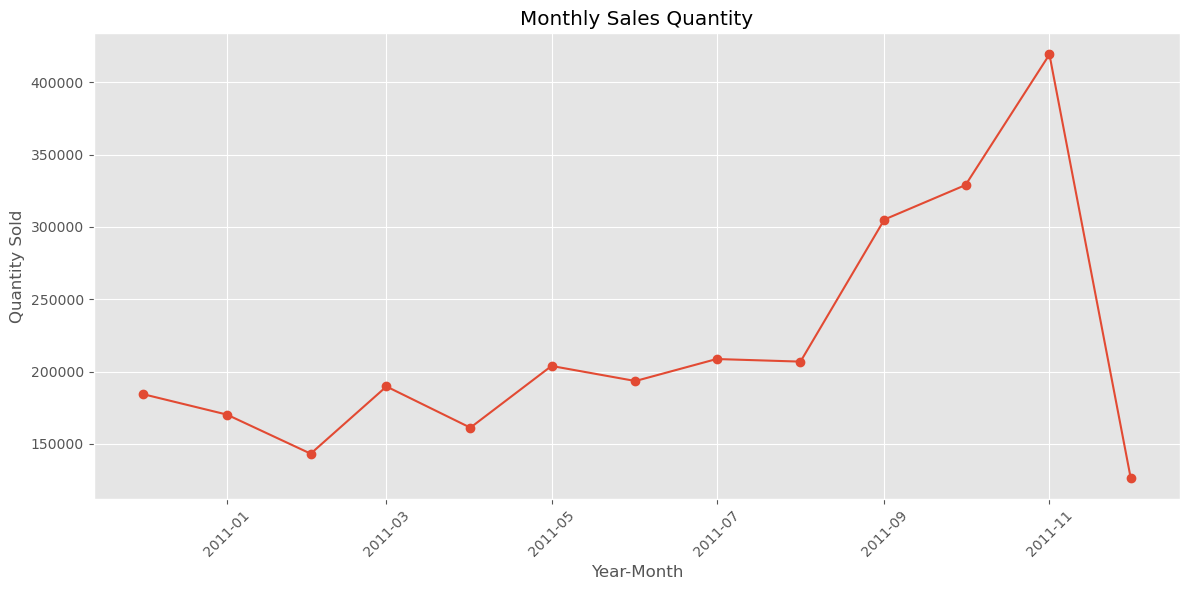

In [75]:
# Fix index safely
if isinstance(sales_qty.index, pd.PeriodIndex):
    sales_qty.index = sales_qty.index.to_timestamp()

peak_month = sales_qty.idxmax()
peak_value = sales_qty.max()

plt.figure(figsize=(12,6))
plt.plot(sales_qty.index, sales_qty.values, marker='o')

plt.scatter(peak_month, peak_value)

plt.title("Monthly Sales Quantity")
plt.xlabel("Year-Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;">  Inference

- The monthly sales trend shows clear fluctuations, with a distinct peak period indicating the highest customer demand and potential seasonality
- Identifying peak and low-performing months helps in better inventory planning, demand forecasting, and targeted marketing strategies

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 6) Analyze Return Trend Analysis </h2>

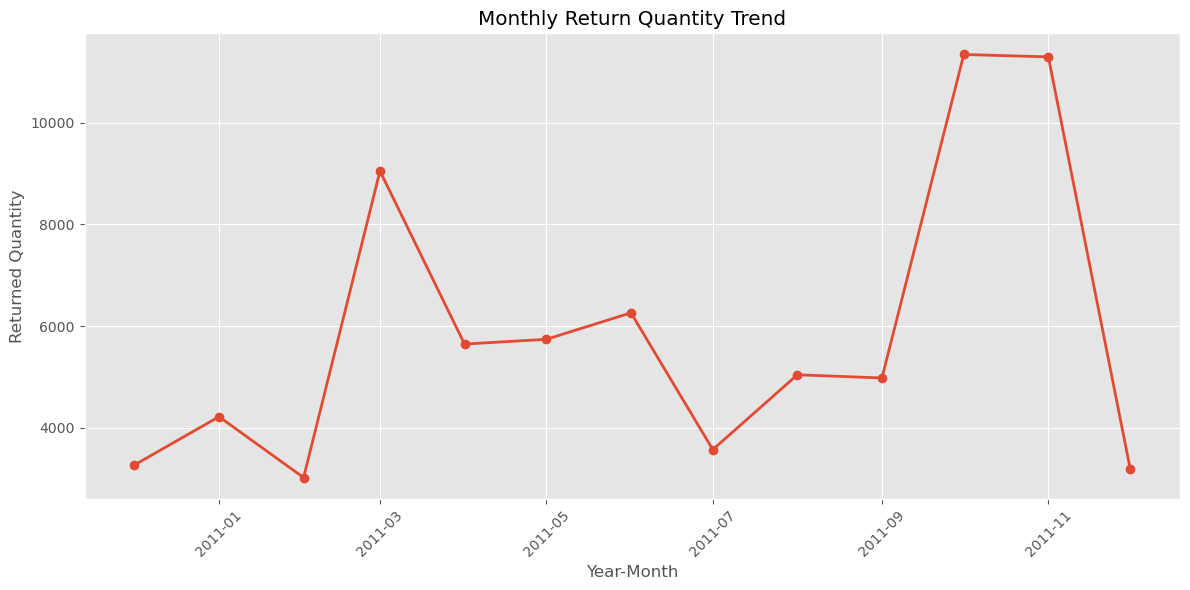

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

return_qty = (
    df[df["Quantity"] < 0]
    .groupby("YearMonth")["Quantity"]
    .sum()
    .abs()
)

# Fix index for plotting
if isinstance(return_qty.index, pd.PeriodIndex):
    return_qty.index = return_qty.index.to_timestamp()

# Identify peak return month
peak_month = return_qty.idxmax()
peak_value = return_qty.max()

plt.figure(figsize=(12, 6))

plt.plot(return_qty.index, return_qty.values, marker='o', linewidth=2)
plt.scatter(peak_month, peak_value)

plt.title("Monthly Return Quantity Trend")
plt.xlabel("Year-Month")
plt.ylabel("Returned Quantity")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The return trend shows noticeable variation across months, with a clear peak indicating periods of higher product returns and potential issues in quality or customer expectations
- Identifying these peak return periods helps businesses take corrective actions to reduce returns and improve overall customer satisfaction

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 7) Analyze Return Rate in(%) </h2>

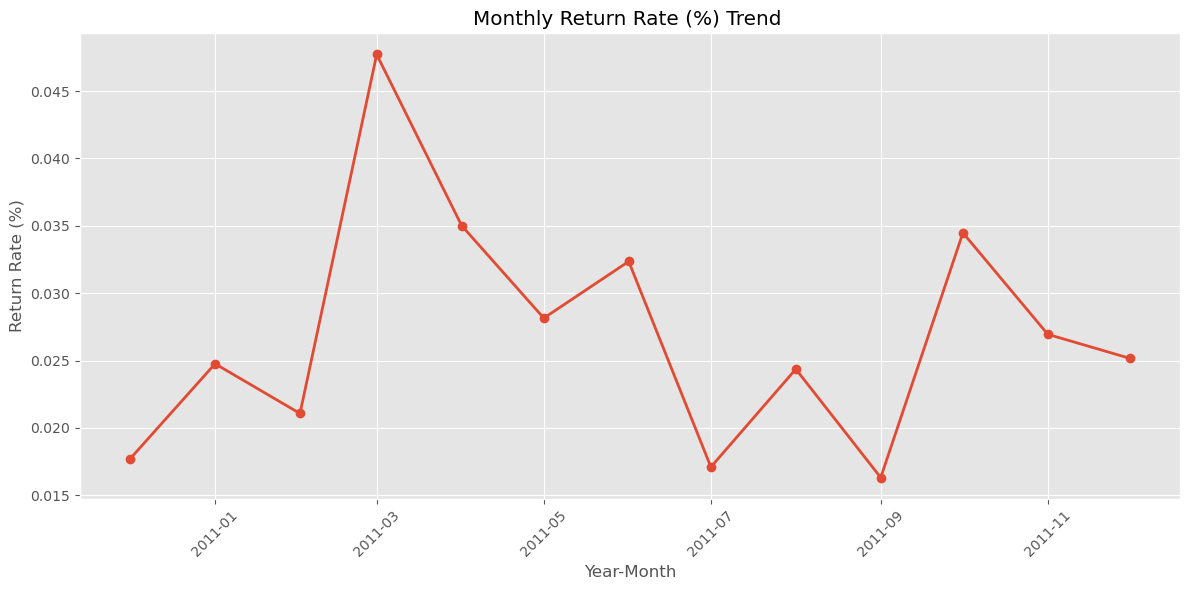

In [29]:
# Return Rate = Returns / Sales
return_rate = return_qty / sales_qty

# Align indexes 
return_rate = return_rate.dropna()

# Identify peak return rate
peak_month = return_rate.idxmax()
peak_value = return_rate.max()

plt.figure(figsize=(12,6))

 
plt.plot(
    return_rate.index,
    return_rate.values,
    marker='o',
    linewidth=2
)


# Highlight peak
plt.scatter(peak_month, peak_value)

plt.title("Monthly Return Rate (%) Trend ")
plt.xlabel("Year-Month")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The return rate trend highlights periods where returns are disproportionately high compared to sales, indicating potential product or customer experience issues
- Monitoring return rate helps identify abnormal spikes and supports better quality control and business decision-making


<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 8) Visualize Total Orders </h2>

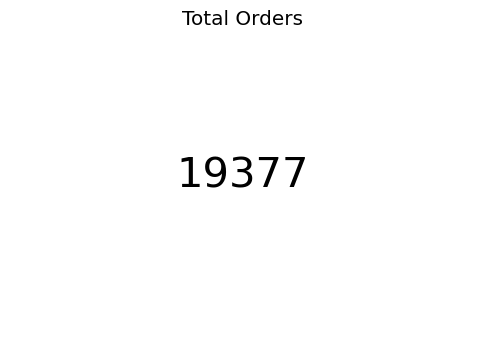

In [78]:
total_orders = df["InvoiceNo"].nunique()

plt.figure(figsize=(6,4))
plt.text(0.5, 0.5, f"{total_orders}", fontsize=30, ha='center')
plt.title("Total Orders")
plt.axis('off')

plt.show()

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 9) Visualize Total Customers </h2>

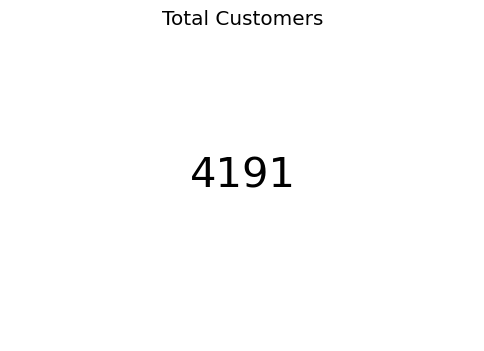

In [30]:
import matplotlib.pyplot as plt

total_customers = df["CustomerID"].nunique()

plt.figure(figsize=(6,4))
plt.text(0.5, 0.5, f"{total_customers}", fontsize=30, ha='center')
plt.title("Total Customers")
plt.axis('off')

plt.show()

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 10) Visualize Avarage Order Value </h2>

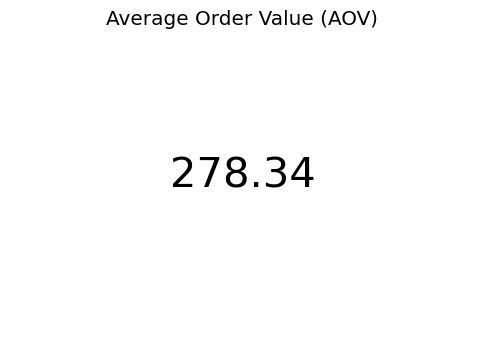

In [32]:
total_orders = df["InvoiceNo"].nunique()
net_revenue = (df["Quantity"] * df["UnitPrice"]).sum()
aov = net_revenue / total_orders
plt.figure(figsize=(6,4))
plt.text(0.5, 0.5, f"{aov:.2f}", fontsize=30, ha='center')
plt.title("Average Order Value (AOV)")
plt.axis('off')

plt.show()

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 11) Analyze Top Selling Products </h2>

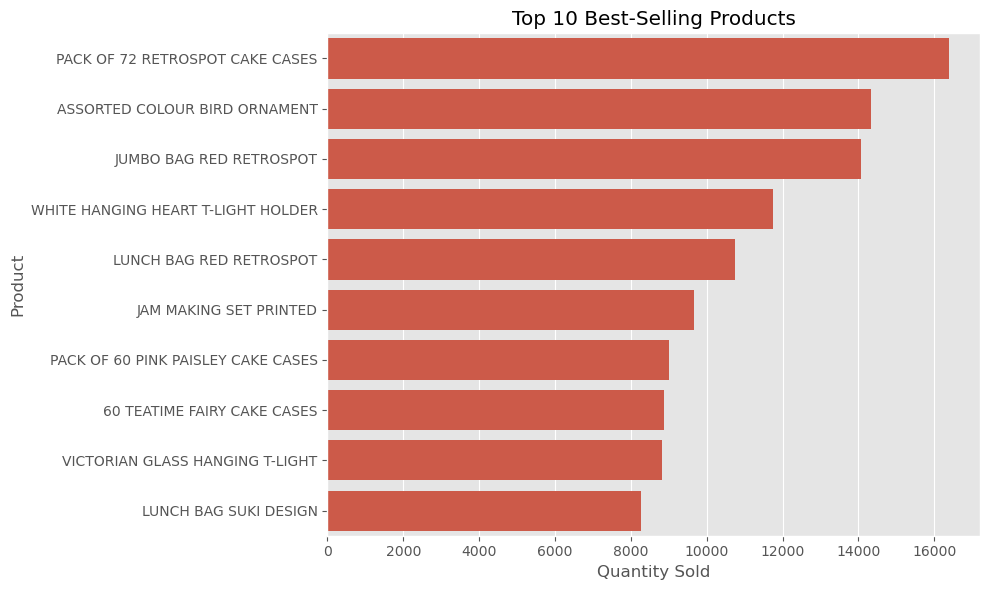

In [33]:
top_products = (
    df_sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products,
    x="Quantity",
    y="Description"
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 12) Analyze Product Return Rate </h2>

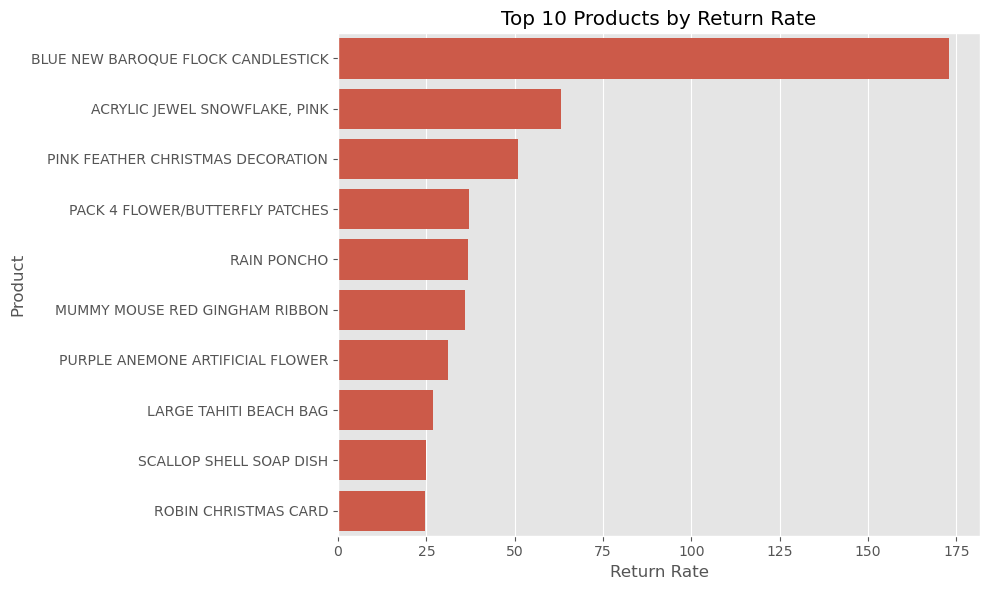

In [35]:
sales_product = (
    df[df["Quantity"] > 0]
    .groupby("Description")["Quantity"]
    .sum()
)

return_product = (
    df[df["Quantity"] < 0]
    .groupby("Description")["Quantity"]
    .sum()
    .abs()
)

return_rate = (return_product / sales_product).dropna()

top_return_rate = return_rate.sort_values(ascending=False).head(10)

top_df = top_return_rate.reset_index()
top_df.columns = ["Description", "ReturnRate"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_df,
    x="ReturnRate",
    y="Description"
)

plt.title("Top 10 Products by Return Rate")
plt.xlabel("Return Rate")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- Certain products exhibit significantly higher return rates, indicating potential issues in product quality, customer expectations, or descriptions
- Identifying these products helps businesses take targeted actions to reduce returns and improve overall profitability

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 13) Analyze  Monthly Revenue Trends </h2>

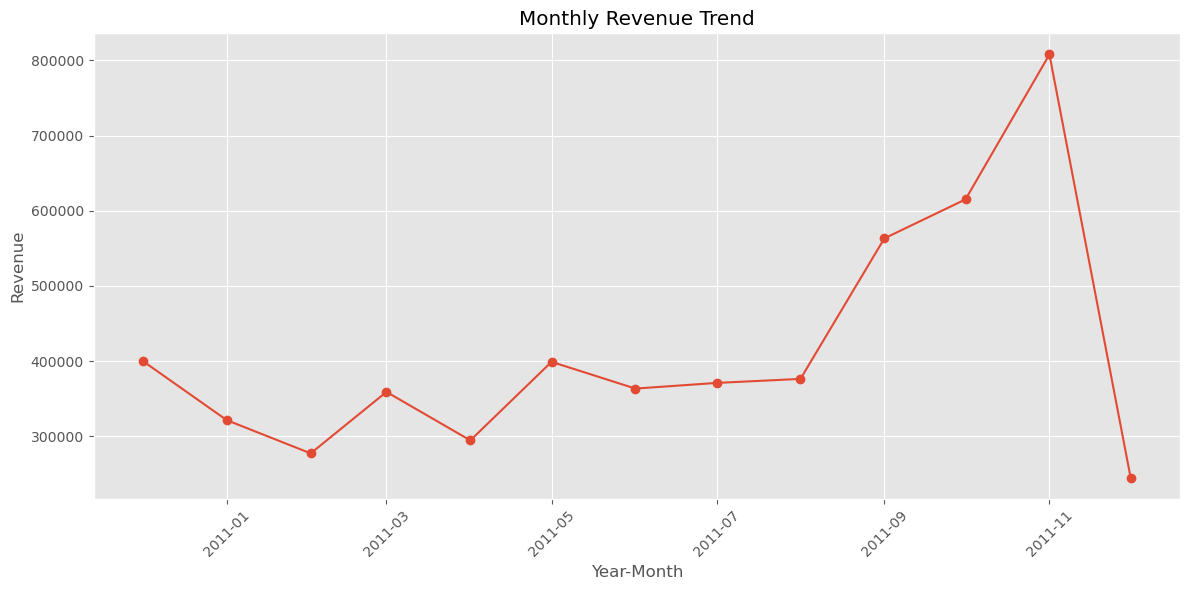

In [54]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Group
monthly = (
    df[df["Quantity"] > 0]
    .groupby("YearMonth")["TotalPrice"]
    .sum()
)

# Fix index if needed
if isinstance(monthly.index, pd.PeriodIndex):
    monthly.index = monthly.index.to_timestamp()

# Identify peak
peak_month = monthly.idxmax()
peak_value = monthly.max()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly.index, monthly.values, marker='o')
plt.scatter(peak_month, peak_value)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The monthly revenue trend shows fluctuations over time, with a clear peak indicating the highest earning period and possible seasonal demand
- Understanding these trends helps businesses optimize pricing, marketing strategies, and inventory planning

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 14) Analyze  Sales Vs Return Comparision </h2>

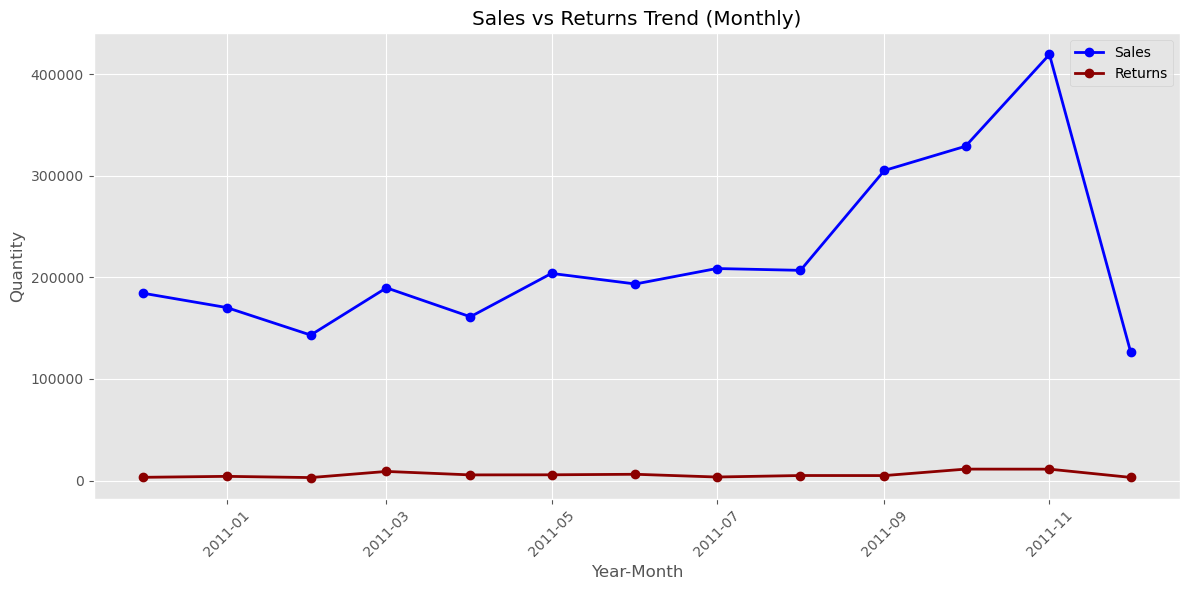

In [63]:
# Sales data
sales = (
    df[df["Quantity"] > 0]
    .groupby("YearMonth")["Quantity"]
    .sum()
)

# Returns data
returns = (
    df[df["Quantity"] < 0]
    .groupby("YearMonth")["Quantity"]
    .sum()
)

# Convert PeriodIndex → DatetimeIndex
if isinstance(sales.index, pd.PeriodIndex):
    sales.index = sales.index.to_timestamp()

if isinstance(returns.index, pd.PeriodIndex):
    returns.index = returns.index.to_timestamp()
    
# Convert returns to positive for clarity
returns_plot = returns.abs()

plt.figure(figsize=(12,6))

plt.plot(sales.index, sales.values, marker='o', linewidth=2, label="Sales", color="blue")
plt.plot(returns_plot.index, returns_plot.values, marker='o', linewidth=2, label="Returns", color="darkred")

plt.title("Sales vs Returns Trend (Monthly)")
plt.xlabel("Year-Month")
plt.ylabel("Quantity")

plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The comparison of sales and returns trends highlights the relationship between demand and product returns over time
- Higher return volumes during peak sales periods may indicate issues in product quality or customer satisfaction

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 15) Analyze Most Returned Products </h2>

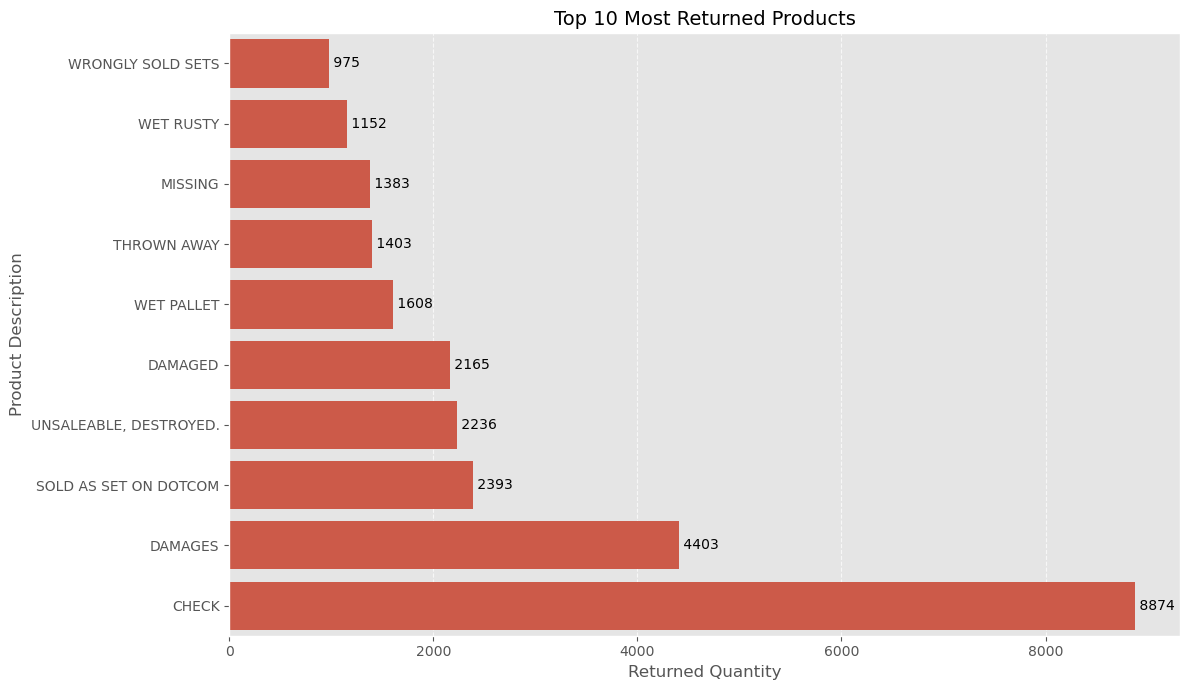

In [56]:
top_returns = (
    df[df["Quantity"] < 0]
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values()
    .head(10)
)

# Prepare data FIRST
top_returns_plot = top_returns.abs().reset_index()

# sort
top_returns_plot = top_returns_plot.sort_values(by="Quantity", ascending=True)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,7))

sns.barplot(
    data=top_returns_plot,
    x="Quantity",
    y="Description"
)

plt.title("Top 10 Most Returned Products", fontsize=14)
plt.xlabel("Returned Quantity", fontsize=12)
plt.ylabel("Product Description", fontsize=12)

# Add value labels
for index, value in enumerate(top_returns_plot["Quantity"]):
    plt.text(value, index, f" {value}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- A small number of products contribute significantly to total returns, indicating potential issues with specific items
- These high-return products should be prioritized for quality checks and customer feedback analysis to reduce return rates

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 16) Analyze Return Rate Per Product </h2>

In [43]:
sales_qty = df[df["Quantity"] > 0].groupby("Description")["Quantity"].sum()
return_qty = df[df["Quantity"] < 0].groupby("Description")["Quantity"].sum().abs()

return_rate = (return_qty / sales_qty).sort_values(ascending=False)
return_rate.head(10)

Description
BLUE NEW BAROQUE FLOCK CANDLESTICK    173.00
ACRYLIC JEWEL SNOWFLAKE, PINK          63.00
PINK FEATHER CHRISTMAS DECORATION      51.00
PACK 4 FLOWER/BUTTERFLY PATCHES        37.00
RAIN PONCHO                            36.75
MUMMY MOUSE RED GINGHAM RIBBON         36.00
PURPLE ANEMONE ARTIFICIAL FLOWER       31.25
LARGE TAHITI BEACH BAG                 27.00
SCALLOP SHELL SOAP DISH                25.00
ROBIN CHRISTMAS CARD                   24.60
Name: Quantity, dtype: float64

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 17) Analyze Customers Analysis </h2>

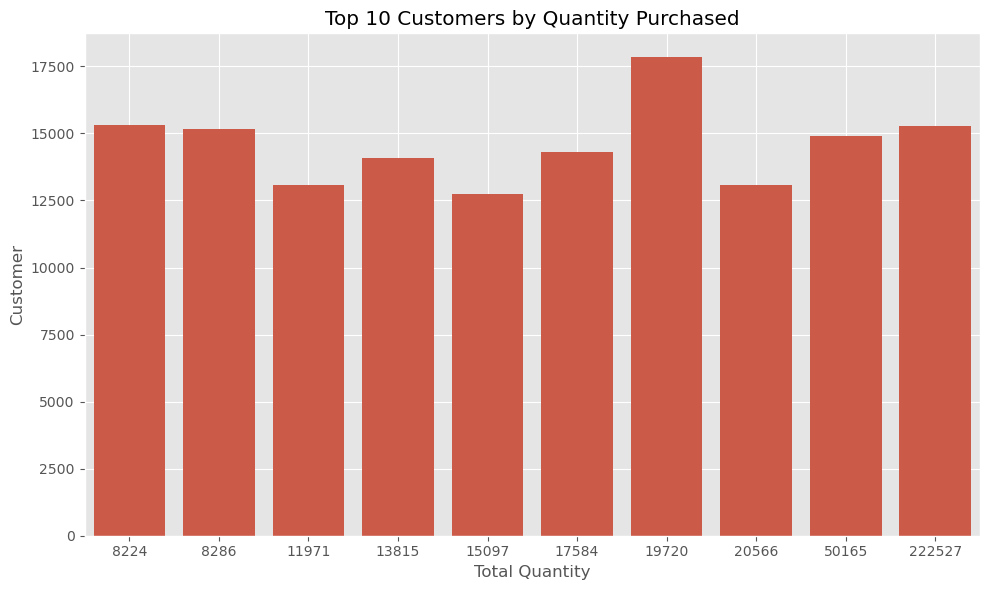

In [44]:
customer_sales = df.groupby("CustomerID")["Quantity"].sum().sort_values(ascending=False)


top_customers = customer_sales.head(10).reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers,
    x="Quantity",
    y="CustomerID"
)

plt.title("Top 10 Customers by Quantity Purchased")
plt.xlabel("Total Quantity")
plt.ylabel("Customer")

plt.grid(axis='x')

plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- A small group of customers contributes significantly to total sales volume, indicating high-value or bulk buyers
- Identifying these top customers helps businesses focus on retention strategies and personalized engagement

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 18) Analyze Country Analysis </h2>

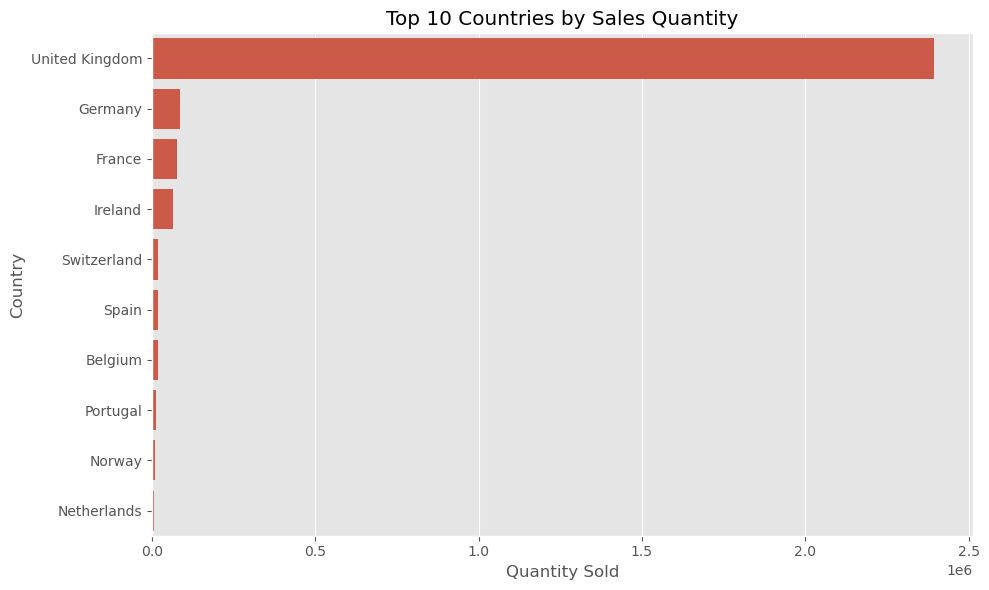

0    88.493541
1     3.133570
2     2.827594
3     2.418491
4     0.693300
5     0.687458
6     0.659209
7     0.453363
8     0.353047
9     0.280426
Name: Quantity, dtype: float64

In [45]:
country_sales = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False)

top_countries = country_sales.head(10).reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_countries,
    x="Quantity",
    y="Country"
)

plt.title("Top 10 Countries by Sales Quantity")
plt.xlabel("Quantity Sold")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

(top_countries["Quantity"] / top_countries["Quantity"].sum()) * 100

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The analysis shows that a few countries contribute significantly higher sales volume, indicating strong market demand in these regions
- This insight helps businesses focus on high-performing markets while identifying opportunities for expansion in lower-performing countries

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 19) Visualize Distribution Analysis </h2>

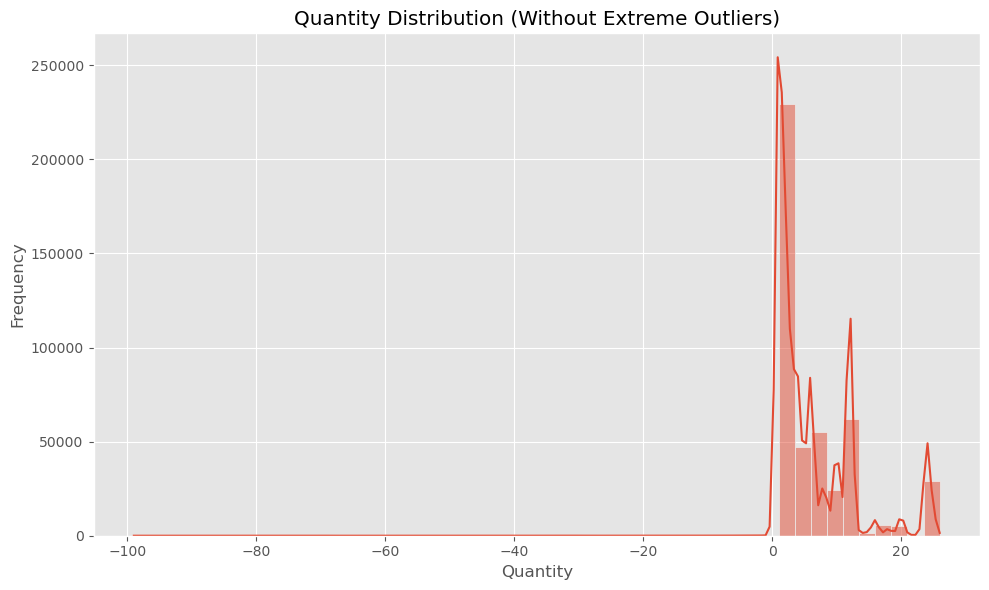

In [46]:
# Remove extreme values for better visualization
filtered_df = df[(df["Quantity"] > -100) & (df["Quantity"] < 100)]

plt.figure(figsize=(10,6))

sns.histplot(filtered_df["Quantity"], bins=50, kde=True)

plt.title("Quantity Distribution (Without Extreme Outliers)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.grid(True)
plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The quantity distribution is highly skewed, with most transactions involving small quantities and a few extreme values indicating bulk purchases or large returns
- Negative values represent returns, highlighting the presence of reverse transactions alongside normal sales

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 20) Visualize Price Distribution </h2>

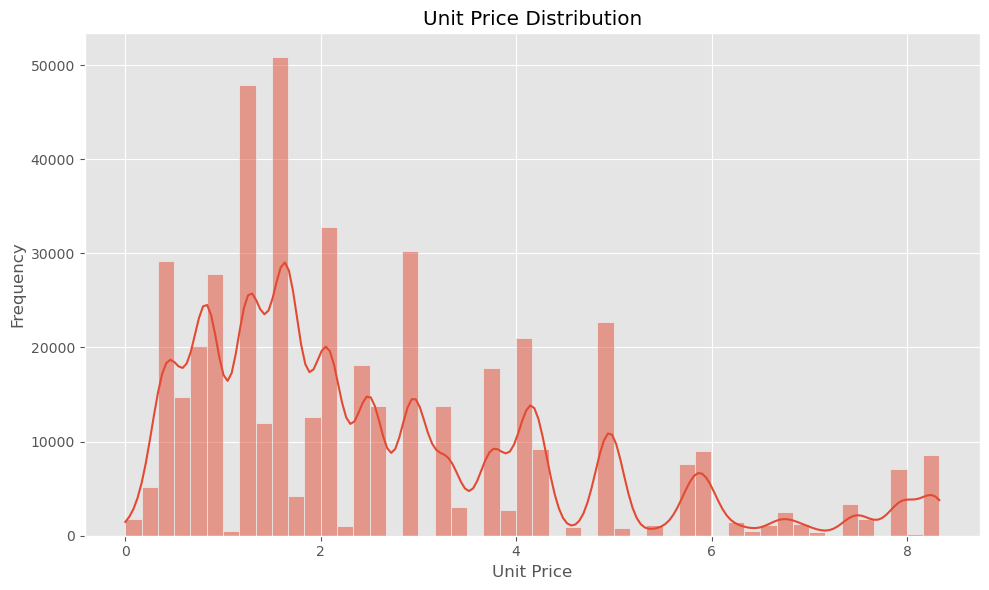

In [47]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["UnitPrice"],
    bins=50,
    kde=True
)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.grid(True)
plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The unit price distribution is right-skewed, indicating that most products are priced at lower ranges with few high-value outliers
- The presence of extreme values suggests premium or bulk-priced products that may impact overall pricing analysis

<h2 style="color:#1F618D; text-align:center; font-weight:bold;"> 21) Analyze Unit Price Vs Quantity </h2>

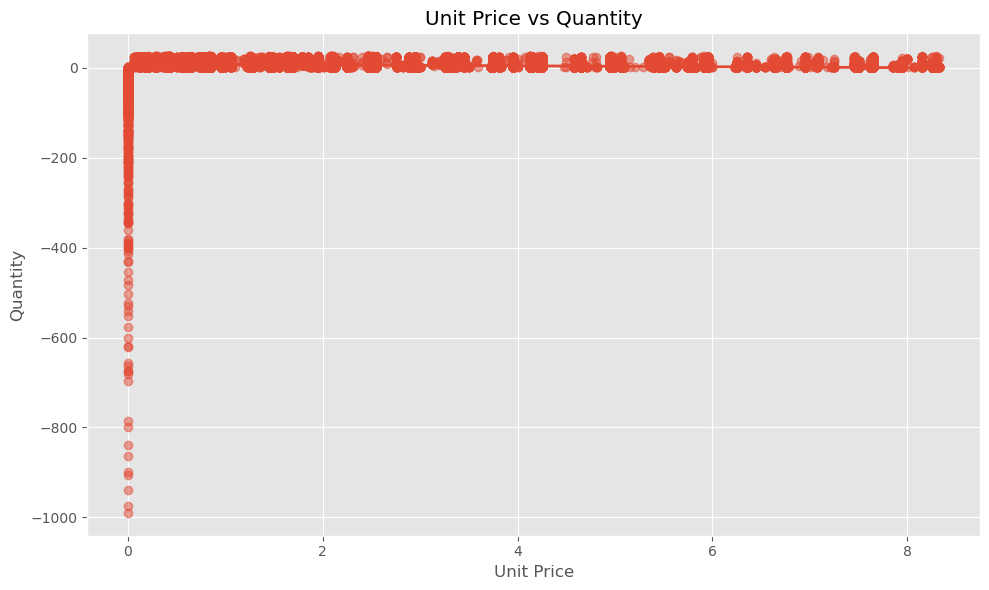

In [57]:
plt.figure(figsize=(10,6))

sns.regplot(
    x="UnitPrice",
    y="Quantity",
    data=df,
    scatter_kws={'alpha':0.5},   # transparency for overlap
    line_kws={'linewidth':2}     # trend line
)

plt.title("Unit Price vs Quantity")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")

plt.grid(True)
plt.tight_layout()
plt.show()

<p style="color: green; font-family:ComicSansMS; font-size: 20px;"> Inference

- The scatter plot with trend line indicates the relationship between unit price and quantity purchased, showing how demand changes with pricing
- A downward (negative) trend suggests that higher prices tend to reduce purchase quantity, indicating price sensitivity among customers